In [28]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as numpy
import matplotlib.pyplot as pyplot

In [29]:
import pandas as pd

df = pd.read_csv("online_shoppers_intention.csv", encoding = "utf-8")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [30]:
# 결측치는 없음으로 판정
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [31]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')

In [32]:
# 1. 값들의 정규화 및 상대화 
# K-NN 분류를 하기 위해서는 값들을 일관된 값으로 바꾸어야한다. 
# 필요한 칼럼은 어떤것이 있을까?

# 페이지 방문 행동 
# Administrative, Administrative_Duration, Informational_Duration, ProductRelated_Duration

# Google Analytics 지표 
# BounceRates, ExitRates, PageValues, SpecialDay

# 세션 메타 정보
# Month, OperatingSystem, Browser, Region, TrafficType, VisitorType, Weekend

# 타겟 변수 
# Revenue

In [33]:
# 페이지 방문 행동만들 사용하여 KNN 회귀분석 활용 
df_new = df[['Administrative', 'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']]
df_new.tail()

,Administrative,Administrative_Duration,Informational_Duration,ProductRelated_Duration
12325,3,145.0,0.0,1783.791667
12326,0,0.0,0.0,465.750000
12327,0,0.0,0.0,184.250000
12328,4,75.0,0.0,346.000000
12329,0,0.0,0.0,21.250000


In [34]:
X = df[['Administrative',
        'Administrative_Duration',
        'Informational_Duration',
        'ProductRelated_Duration']]
y = df['Revenue']

In [35]:
# Create and train model
# 임의로 k값 설정(실험적으로 결정할 예정)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# Predict a new Person
# 테스트 시에도 4개의 값을
predicted_class = knn.predict([[3, 90, 0, 800]])[0]
print("Predicted class : ", predicted_class) # false 구매를 하지 않는 사람임

Predicted class :  False


e:\DataMiningTerm\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [38]:
# 해당 5개의 칼럼에 대한 정보를 그리기 위해서는 2번의 PCA(차원축소)를 진행해야합니다.
# K-NN, PCA 는 스케일 차이에 민감하니까 먼저 표준화합니다.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) # 표준화

In [39]:
# 그다음 2차원 축소
from sklearn.decomposition import PCA

# n_components 는 축소할 차원의 개수
pca = PCA(n_components = 2) 
X_pca = pca.fit_transform(X_scaled) # 표준화한 값을 차원 축소 arg로 사용

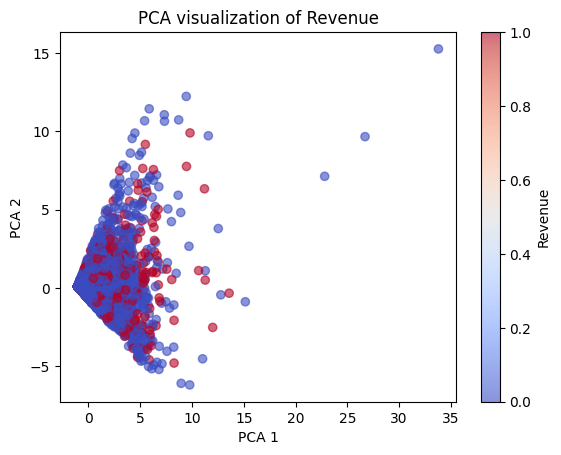

In [44]:
# 그래프 그리기 
import matplotlib.pyplot as plt

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c = y,
    cmap = 'coolwarm',
    alpha = 0.6
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA visualization of Revenue')
plt.colorbar(label = 'Revenue')
plt.show()